# 🧹 Préparation du Dataset BTC Tweets 📊

Ce notebook prépare le jeu de données **BTC_Tweets_Sentiments.csv**, contenant des tweets annotés manuellement selon leur **polarité** (positive ou négative). Il est utilisé pour entraîner un modèle de classification des sentiments en lien avec le Bitcoin. 🪙

## Objectifs 🎯
- Nettoyer les tweets (ponctuation, mentions, hashtags...)
- Visualiser la distribution des sentiments
- Préparer un jeu d'entraînement équilibré et robuste
- Créer des jeux d'entraînement, validation et test
- Déduire des hyperparamètres pertinents pour l'entrainement à partir des données
- Sauvegarder les datasets dans le dossier `data/` avec un format adapté aux modèles BERT
- Sauvegarder les datasets dans le dossier `data/distilroberta` avec un nettoyage du<br>  texte preservant la casse et la ponctuation.


## 🔍 Importation des librairies et Chargement du Dataset

In [22]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.utils import resample
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

In [23]:
# Nettoyage des anciens fichiers
for split in ["train.csv", "val.csv", "test.csv"]:
    path = f"../dataset/{split}"
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Supprimé : {path}")

In [24]:
# Chargement du dataset
try:
    df = pd.read_csv("../data/BTC_Tweets_Sentiments.csv", encoding="utf-8")
    df.head(10)
except FileNotFoundError:
    print("Erreur : le fichier spécifié est introuvable.")
except pd.errors.EmptyDataError:
    print("Erreur : le fichier est vide.")
except pd.errors.ParserError:
    print("Erreur : échec de l'analyse du fichier.")
except Exception as e:
    print(f"Une erreur inattendue est survenue : {e}")

## 🏷️ Nettoyage et encodage des sentiments

Dans cette étape, nous nettoyons la colonne `Sentiment` pour supprimer les caractères inutiles (`[`, `]`, `'`) qui peuvent provenir d’une mauvaise importation ou annotation.

Ensuite, nous ne conservons que les tweets **positifs** et **négatifs**, en excluant les neutres ou mal étiquetés.  
Enfin, nous encodons les labels pour la classification binaire :
- `0` pour **négatif**
- `1` pour **positif**

🧼 Ce prétraitement est indispensable pour préparer les données à l'entraînement d’un modèle de classification supervisée.

In [25]:
df['Sentiment'] = df['Sentiment'].str.replace(r"[\[\]']", "", regex=True).str.strip()
df = df[df['Sentiment'].isin(['positive', 'negative'])].reset_index(drop=True)
df['label'] = df['Sentiment'].map({'negative': 0, 'positive': 1})
df.head()

,id,Date,Tweet,Screen_name,Source,Link,Sentiment,sent_score,New_Sentiment_Score,New_Sentiment_State,BERT Labels,label
0,2,Fri Mar 23 00:40:35 +0000 2018,RT @tippereconomy: Another use case for #block...,hojachotopur,"[u'blockchain', u'Tipper', u'TipperEconomy']","<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.136364,1.0,0,1
1,3,Fri Mar 23 00:40:36 +0000 2018,free coins https://t.co/DiuoePJdap,denies_distro,[],"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.400000,1.0,0,1
2,4,Fri Mar 23 00:40:36 +0000 2018,RT @payvxofficial: WE are happy to announce th...,aditzgraha,[],"<a href=""http://twitter.com/download/android"" ...",positive,1.0,0.468182,1.0,0,1
3,5,Fri Mar 23 00:40:36 +0000 2018,Copy successful traders automatically with Bit...,VictorS61164810,[],"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.750000,1.0,1,1
4,6,Fri Mar 23 00:40:37 +0000 2018,RT @bethereumteam: We're revealing our surpris...,ClarkKalel4,"[u'surprise', u'presents', u'crypto', u'bitcoin']","<a href=""http://twitter.com/download/android"" ...",positive,1.0,0.200000,1.0,0,1


## 🧹 Nettoyage du texte des tweets

Avant d’analyser les tweets, il est crucial de les nettoyer pour enlever le bruit et les éléments inutiles à la compréhension du modèle.  
Voici les opérations effectuées :

- Suppression des liens (`http...`)
- Suppression des mentions Twitter (`@username`)
- Suppression du caractère `#` des hashtags
- Suppression de toute ponctuation ou caractère spécial
- Suppression du tag `rt`
- Suppression des espaces inutiles
- Conversion en minuscules pour uniformiser

🔤 Cela permet d'obtenir un texte plus propre et cohérent, stocké dans une nouvelle colonne `clean_text`, que nous utiliserons pour l'entraînement du modèle.

In [26]:
def clean_text(text):
    text = re.sub(r"http\S+|@\S+|#[A-Za-z0-9_]+", "", text)         # Supprimer les URLs, mentions et hashtags
    text = re.sub(r"([-+]?\d+(?:\.\d+)?)%", r"\1 percent", text)    # Transformer les pourcentages, en gardant le signe
    text = re.sub(r"\brt\b", "", text, flags=re.IGNORECASE)         # Supprimer "rt" en tant que mot seul
    text = text.replace("amp", "")                                  # Supprimer "amp" (artefact HTML)

    # Supprimer les caractères spéciaux sauf lettres, chiffres, emojis, et les signes + -
    text = re.sub(r"[^\w\s\.\-\+"
                  "\U0001F600-\U0001F64F"                            # Emoticons
                  "\U0001F300-\U0001F5FF"                            # Symbols & pictographs
                  "\U0001F680-\U0001F6FF"                            # Transport & map
                  "\U0001F1E0-\U0001F1FF"                            # Flags
                  "]", "", text)

    # Supprimer les signes + ou - s'ils ne sont pas devant un chiffre
    text = re.sub(r"(?<!\d)[+-](?!\d)", "", text)

    text = re.sub(r"\s+", " ", text)                                # Normaliser les espaces
    return text.lower().strip()                                     # Mettre en minuscules et supprimer les espaces en trop

# Test avant de traiter le vrai dataset
test_data = pd.DataFrame({
    "Tweet": [
        "rt The price dropped by -5.2% today 😱 #crypto -WHAOU- @+ @johndoe",
        "Huge gain: +7.45% 🚀 #bitcoin https://www.atom.com/name/Test WOnDeRful!",
        "Still stable at 0.0% 🙂 !!!!",
        "Volume increased 15% 📈",
        "Loss recorded: -0.85% 😓     ",
        "only% %% %"
    ]
})

test_data["clean_text"] = test_data["Tweet"].apply(clean_text)
with pd.option_context('display.max_colwidth', None):
    display(test_data)

# Copie du jeu de données original pour préparer une version adaptée à DistilRoBERTa,
# qui est sensible à la casse et à la ponctuation (contrairement à BERTweet ou DistilBERT)
df_roberta = df.copy()

# Traitement du dataset final
df["clean_text"] = df["Tweet"].apply(clean_text)
df.head()

,Tweet,clean_text
0,rt The price dropped by -5.2% today 😱 #crypto -WHAOU- @+ @johndoe,the price dropped by -5.2 percent today 😱 whaou
1,Huge gain: +7.45% 🚀 #bitcoin https://www.atom.com/name/Test WOnDeRful!,huge gain +7.45 percent 🚀 wonderful
2,Still stable at 0.0% 🙂 !!!!,still stable at 0.0 percent 🙂
3,Volume increased 15% 📈,volume increased 15 percent 📈
4,Loss recorded: -0.85% 😓,loss recorded -0.85 percent 😓
5,only% %% %,only


,id,Date,Tweet,Screen_name,Source,Link,Sentiment,sent_score,New_Sentiment_Score,New_Sentiment_State,BERT Labels,label,clean_text
0,2,Fri Mar 23 00:40:35 +0000 2018,RT @tippereconomy: Another use case for #block...,hojachotopur,"[u'blockchain', u'Tipper', u'TipperEconomy']","<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.136364,1.0,0,1,another use case for and . the can unseat face...
1,3,Fri Mar 23 00:40:36 +0000 2018,free coins https://t.co/DiuoePJdap,denies_distro,[],"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.400000,1.0,0,1,free coins
2,4,Fri Mar 23 00:40:36 +0000 2018,RT @payvxofficial: WE are happy to announce th...,aditzgraha,[],"<a href=""http://twitter.com/download/android"" ...",positive,1.0,0.468182,1.0,0,1,we are happy to announce that payvx presale ph...
3,5,Fri Mar 23 00:40:36 +0000 2018,Copy successful traders automatically with Bit...,VictorS61164810,[],"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",positive,1.0,0.750000,1.0,1,1,copy successful traders automatically with bit...
4,6,Fri Mar 23 00:40:37 +0000 2018,RT @bethereumteam: We're revealing our surpris...,ClarkKalel4,"[u'surprise', u'presents', u'crypto', u'bitcoin']","<a href=""http://twitter.com/download/android"" ...",positive,1.0,0.200000,1.0,0,1,were revealing our surprise tomorrow are you r...


## 🧹 Suppression des doublons (retweet...) et des textes vides

In [27]:
before = len(df)
df = df[~df["clean_text"].isna()]  # supprime les NaN
df = df[df["clean_text"].str.strip() != ""]  # supprime les chaînes vides ou avec seulement des espaces
df = df.reset_index(drop=True)
after = len(df)
print(f"🧹 Removed {before - after} empty or whitespace-only entries.")

🧹 Removed 1 empty or whitespace-only entries.


In [28]:
before = len(df)
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
after = len(df)
print(f"🧹 Removed {before - after} duplicate entries.")

🧹 Removed 19533 duplicate entries.


## 📊 Analyse Exploratoire (EDA)

Après avoir nettoyé les textes, explorons notre jeu de données pour mieux comprendre sa structure et identifier d'éventuels biais.

### 🔢 Répartition des classes

Nous vérifions la distribution des tweets positifs et négatifs afin de repérer un éventuel déséquilibre.  
Un déséquilibre fort pourrait nécessiter un rééchantillonnage (oversampling/undersampling).


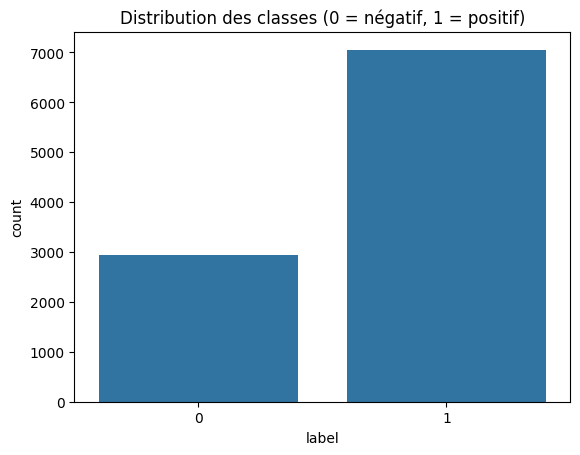

Le jeu de données est déséquilibré :
  • Tweets négatifs : 2931
  • Tweets positifs : 7055

➡️ On applique un **upsampling** de la classe minoritaire pour équilibrer
les classes sans perte d’information (plutôt qu’un downsampling destructif).


In [29]:
# Répartition des classes
sns.countplot(data=df, x="label")
plt.title("Distribution des classes (0 = négatif, 1 = positif)")
plt.show()

# Résumé et justification
neg, pos = df['label'].value_counts().sort_index().tolist()
print(
    f"Le jeu de données est déséquilibré :\n"
    f"  • Tweets négatifs : {neg}\n"
    f"  • Tweets positifs : {pos}\n\n"
    f"➡️ On applique un **upsampling** de la classe minoritaire pour équilibrer\n"
    f"les classes sans perte d’information (plutôt qu’un downsampling destructif)."
)

### 📏 Distribution des longueurs de texte

Les modèles comme BERT ont une longueur maximale d’entrée.  
Analyser la longueur des tweets permet de décider s’il faut tronquer ou ajuster la tokenisation.


📏 Statistiques sur la longueur des tweets (en mots) :
   ➕ Moyenne       : 14.1 mots
   🟰 Médiane       : 15 mots
   🔽 Minimum       : 1 mots
   🔼 Maximum       : 35 mots
   🧮 75e percentile: 18 mots


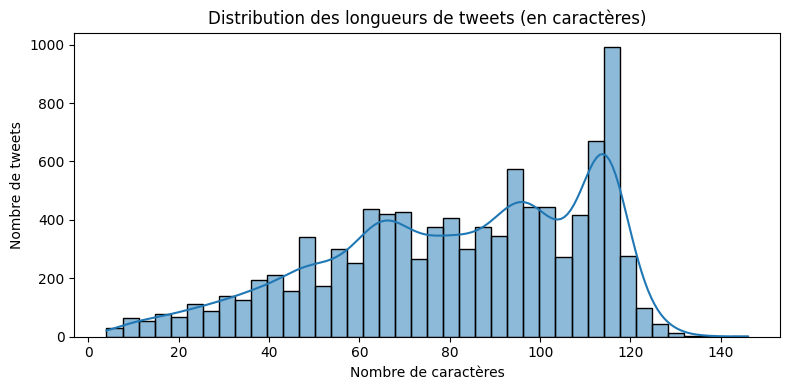

In [30]:
# 📊 Statistiques descriptives sur la longueur des textes (en mots)
df["text_length_words"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\n📏 Statistiques sur la longueur des tweets (en mots) :")
print(f"   ➕ Moyenne       : {df['text_length_words'].mean():.1f} mots")
print(f"   🟰 Médiane       : {df['text_length_words'].median():.0f} mots")
print(f"   🔽 Minimum       : {df['text_length_words'].min()} mots")
print(f"   🔼 Maximum       : {df['text_length_words'].max()} mots")
print(f"   🧮 75e percentile: {np.percentile(df['text_length_words'], 75):.0f} mots")

# 📉 Distribution de la longueur des textes (en caractères)
df["text_length"] = df["clean_text"].apply(len)
plt.figure(figsize=(8, 4))
sns.histplot(df["text_length"], bins=40, kde=True)
plt.title("Distribution des longueurs de tweets (en caractères)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de tweets")
plt.tight_layout()
plt.show()


📏 Statistiques sur la longueur des tweets (en mots) :
   ➕ Moyenne       : 14.1 mots
   🟰 Médiane       : 15 mots
   🔽 Minimum       : 1 mots
   🔼 Maximum       : 35 mots
   🧮 75e percentile: 18 mots


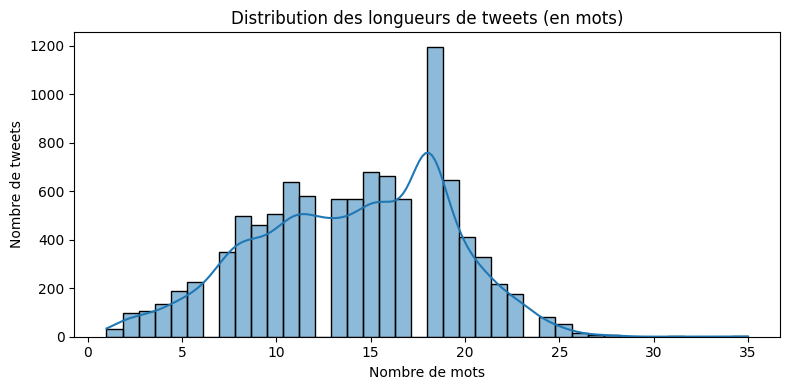

In [31]:
# 📊 Statistiques descriptives sur la longueur des textes (en mots)
df["text_length_words"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\n📏 Statistiques sur la longueur des tweets (en mots) :")
print(f"   ➕ Moyenne       : {df['text_length_words'].mean():.1f} mots")
print(f"   🟰 Médiane       : {df['text_length_words'].median():.0f} mots")
print(f"   🔽 Minimum       : {df['text_length_words'].min()} mots")
print(f"   🔼 Maximum       : {df['text_length_words'].max()} mots")
print(f"   🧮 75e percentile: {np.percentile(df['text_length_words'], 75):.0f} mots")

# 📉 Distribution de la longueur des textes (en mots)
plt.figure(figsize=(8, 4))
sns.histplot(df["text_length_words"], bins=40, kde=True)
plt.title("Distribution des longueurs de tweets (en mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de tweets")
plt.tight_layout()
plt.show()

### 📈 Nuage de mots (`WordCloud`)

Visualisation des mots les plus fréquents dans chaque classe (positif et négatif).  
Cela permet d'identifier rapidement les tendances lexicales ou les biais de langage.

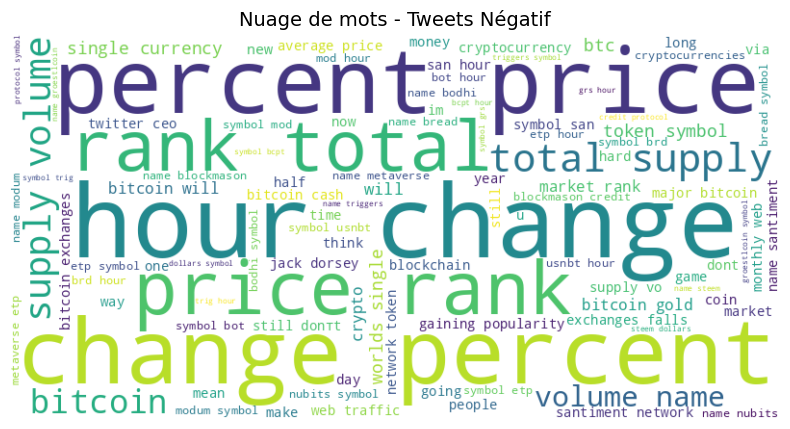

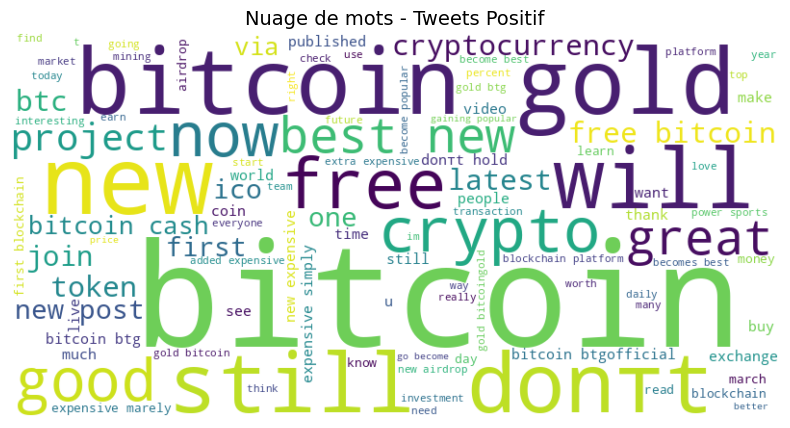

In [32]:
# Génération des nuages de mots
for label_value, label_name in zip([0, 1], ['Négatif', 'Positif']):
    text = " ".join(df[df['label'] == label_value]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nuage de mots - Tweets {label_name}", fontsize=14)
    plt.show()

### 🧮 Mots les plus fréquents (`CountVectorizer`)

Analyse quantitative des mots les plus présents dans le corpus, utile pour comparer les différences lexicales entre les classes.

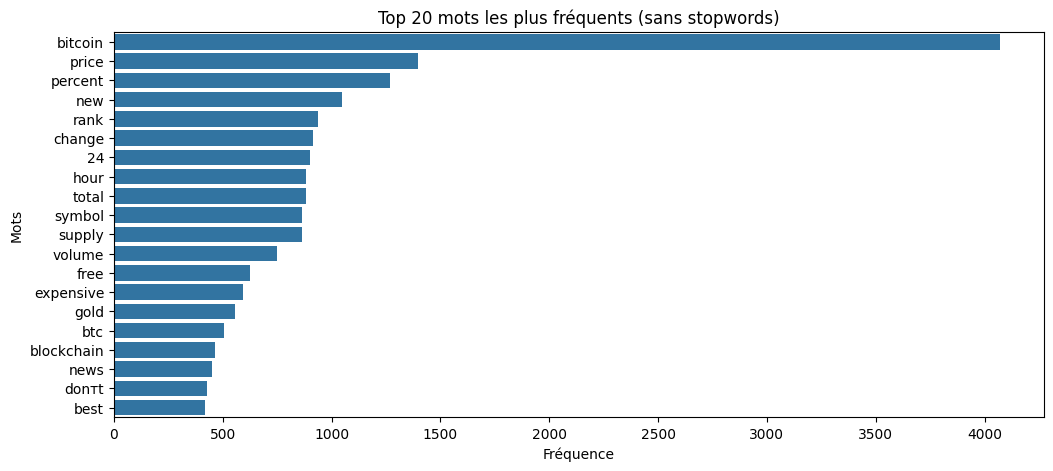

In [33]:
# Exclure les stopwords
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df["clean_text"])

# Récupération des fréquences
word_counts = X.toarray().sum(axis=0)
vocab = vectorizer.get_feature_names_out()
word_freq = dict(zip(vocab, word_counts))

# Top 20 mots les plus fréquents
common_words = Counter(word_freq).most_common(20)
words, freqs = zip(*common_words)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(freqs), y=list(words))
plt.title("Top 20 mots les plus fréquents (sans stopwords)")
plt.xlabel("Fréquence")
plt.ylabel("Mots")
plt.show()

### 📊 Boxplot des longueurs de tweet par classe

Permet de visualiser si les tweets positifs sont en moyenne plus longs que les négatifs, ou vice versa.

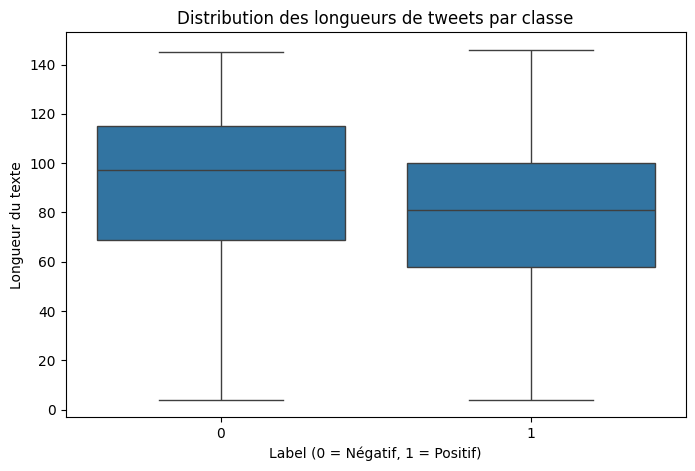

In [34]:
# longueurs de tweets par classe
df["text_length"] = df["clean_text"].apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="text_length", data=df)
plt.title("Distribution des longueurs de tweets par classe")
plt.xlabel("Label (0 = Négatif, 1 = Positif)")
plt.ylabel("Longueur du texte")
plt.show()

## ⚖️ Équilibrage des classes
Le jeu de données est déséquilibré, avec une majorité de tweets positifs.<br>🎯 Pour éviter que le modèle ne développe un biais, on applique un **upsampling**<br>de la classe minoritaire afin d’obtenir une répartition équilibrée (50/50), sans perte d’information.

In [35]:
pos = df[df['label'] == 1]
neg = df[df['label'] == 0]

# Upsample la classe minoritaire (ici négatifs)
neg_upsampled = resample(neg, 
                         replace=True, 
                         n_samples=len(pos), 
                         random_state=42)

df_balanced = pd.concat([pos, neg_upsampled]).sample(frac=1, random_state=42)

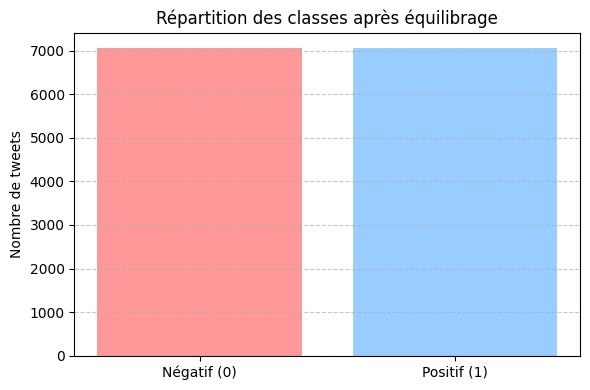

Tweets négatifs : 7055
Tweets positifs : 7055


In [36]:
# Visualisation de la répartition après équilibrage
counts = df_balanced['label'].value_counts().sort_index()
labels = ['Négatif (0)', 'Positif (1)']
colors = ['#ff9999','#99ccff']
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=colors)
plt.title('Répartition des classes après équilibrage')
plt.ylabel('Nombre de tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Tweets négatifs : {df_balanced[df_balanced.label == 0].shape[0]}")
print(f"Tweets positifs : {df_balanced[df_balanced.label == 1].shape[0]}")

## 🧾 Réindexation & colonnes utiles

On réinitialise les index, attribue un identifiant unique (id), puis on ne conserve que les colonnes essentielles : `id`, `Tweet`, `clean_text` et `label`.

In [37]:
# Réindexation propre : suppression de l'ancien id si présent
if 'id' in df_balanced.columns:
    df_balanced.drop(columns=['id'], inplace=True)

# Réinitialiser les index et ajouter un ID de 1 à N
df_balanced = df_balanced.reset_index(drop=True)
df_balanced.insert(0, 'id', range(1, len(df_balanced) + 1))

# Ne conserver que les colonnes utiles et renommer Tweet en full_text
df_balanced = df_balanced[['id', 'Tweet', 'clean_text', 'label']]
df_balanced = df_balanced.rename(columns={"Tweet": "full_text"})
df_balanced.head(10)

,id,full_text,clean_text,label
0,1,@alexmoiseev82 Bitcoin BTG(OFFICIAL) (Bitcoin ...,bitcoin btgofficial bitcoin gold and gaining p...,1
1,2,Agent option reason ever father whether wall w...,agent option reason ever father whether wall w...,0
2,3,Bitcoin Gold (CRYPTO:BTG) Trading Down 8.1% Th...,bitcoin gold cryptobtg trading down 8.1 percen...,0
3,4,Long or Short GOLD using Bitcoin. Max leverage...,long or short gold using bitcoin. max leverage...,0
4,5,https://t.co/eRRzz6VA4t Is In Talks to Buy One...,is in talks to buy one of bitcoins best funded...,1
5,6,Upbit Announces Launch of Korea's First Crypto...,upbit announces launch of koreas first cryptoc...,1
6,7,"RT @CoinbayExchange: #Giveaway 1,000 CBY -Retw...",1000 cby retweet follow comment down below wit...,0
7,8,"Binance Calls FAKE NEWS! Bitcoin Charting, and...",binance calls fake news bitcoin charting and a...,0
8,9,@grockrecords2 Bitcoin -Gold (Bitcoin-Gold) ar...,bitcoin gold bitcoingold are become popularity...,0
9,10,💎 The project is VERY promising!!!\n \n🔥 AIRDR...,💎 the project is very promising 🔥 airdrop even...,1


## 📏 Estimation de `max_length` pour la tokenisation sur le dataset final

Avant de fine-tuner un modèle de type BERT ou BERTweet, il est essentiel d'estimer une longueur maximale (`max_length`) adaptée pour la tokenisation.

- Si la longueur est trop courte, on perd de l'information (troncature).
- Si elle est trop longue, on gaspille de la mémoire GPU/CPU inutilement.

In [38]:
# Liste des modèles à comparer
models = {
    "vinai/bertweet-base": "BERTweet",
    "distilbert-base-uncased": "DistilBERT"
}

token_lengths = {}

for model_name, label in models.items():
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    lengths = df_balanced["clean_text"].apply(lambda x: len(tokenizer.tokenize(x)))
    p95 = np.percentile(lengths, 95)
    p99 = np.percentile(lengths, 99)
    token_lengths[label] = int(p99)

    print(f"📊 {label}")
    print(f"   🔹 95e percentile : {int(p95)} tokens")
    print(f"   🔹 99e percentile : {int(p99)} tokens\n")

# Choix du max_length optimal
max_length = max(token_lengths.values())

# Arrondi à la puissance de 2 supérieure
def next_power_of_2(x):
    return 2 ** int(np.ceil(np.log2(x)))

max_length_rounded = next_power_of_2(max_length)

print(f"✅ max_length retenu : {max_length_rounded} tokens (puissance de 2 la plus proche ≥ {max_length})")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


📊 BERTweet
   🔹 95e percentile : 31 tokens
   🔹 99e percentile : 33 tokens

📊 DistilBERT
   🔹 95e percentile : 36 tokens
   🔹 99e percentile : 39 tokens

✅ max_length retenu : 64 tokens (puissance de 2 la plus proche ≥ 39)


## 📁 Découpage en jeux d'entraînement/validation/test

In [39]:
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (9877, 4)
Validation: (2116, 4)
Test: (2117, 4)


## 💾 Sauvegarde des Datasets

In [40]:
os.makedirs("./data", exist_ok=True)

train_df.to_csv("./data/train.csv", index=False, encoding="utf-8")
val_df.to_csv("./data/val.csv", index=False, encoding="utf-8")
test_df.to_csv("./data/test.csv", index=False, encoding="utf-8")

print("Fichiers exportés dans le dossier data/")

Fichiers exportés dans le dossier data/


## 📊 Conclusion: Estimation des hyperparamètres

| Hyperparamètre      | Description                                              | Comment l’EDA aide à le définir                                                                                                                             | Recommandation                        |
| ------------------- | -------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------- |
| **`max_length`**    | Longueur maximale des séquences (en tokens)              | 🔍 *EDA → Distribution des longueurs de textes (en tokens)* : permet de fixer une limite pour éviter le padding excessif          | 64 tokens                              |
| **`batch_size`**    | Nombre d’exemples par lot (batch)                        | 🧮 *EDA → Taille moyenne des textes* : plus les séquences sont longues, plus on réduit `batch_size` pour éviter une surcharge mémoire (CPU/GPU)             | 32                                        |
| **`epochs`**        | Nombre d’itérations complètes sur l’ensemble des données | 📈 *EDA → Volume de données* : plus le dataset est grand, moins on a besoin de beaucoup d’epochs. On ajoutera `EarlyStopping` dans les callbacks de l'entrainement pour éviter l’overfitting.         | 10                                        |
| **`learning_rate`** | Taux de mise à jour des poids lors de l’optimisation     | ⚙️ *EDA indirect* : pas lié à une statistique brute, mais à la complexité des données (variabilité, bruit). Prendre la valeur typique pour les modèles BERT. | 2e-5                                  |
| **`tokenizer`**     | Type de tokeniseur à utiliser selon le modèle            | 📚 *EDA → Langue, style et longueur des textes* : pour du langage Twitter en anglais, BERTweet et DistilBERT sont recommandé            | BERTweet DistilBERT en fonction du modèle |


## 📦 Export d’un dataset adapté à DistilRoBERTa
Les modèles Roberta sont sensibles à la casse et à la ponctuation.<br>Pour les comparer de façon juste, ce jeu de données ne passe pas par la mise en minuscule.<br>Le reste du pipeline (EDA, équilibrage, splits) reste identique.

In [43]:
# Nettoyage adapté pour RoBERTa : on conserve la casse et la ponctuation
def clean_text_roberta(text: str) -> str:
    text = re.sub(r"http\S+|@\S+|#[A-Za-z0-9_]+", "", text)         # URLs, mentions, hashtags
    text = re.sub(r"([-+]?\d+(?:\.\d+)?)%", r"\1 percent", text)    # Pourcentages
    text = re.sub(r"\brt\b", "", text, flags=re.IGNORECASE)         # "rt" seul
    text = text.replace("amp", "")                                  # Artefact HTML

    text = re.sub(r"[^\w\s\.\-\+"                                   
                  "\U0001F600-\U0001F64F"
                  "\U0001F300-\U0001F5FF"
                  "\U0001F680-\U0001F6FF"
                  "\U0001F1E0-\U0001F1FF"
                  "]", "", text)                                    # Caractères spéciaux
    text = re.sub(r"(?<!\d)[+-](?!\d)", "", text)                   # + / - isolés
    text = re.sub(r"\s+", " ", text)                                # Espaces superflus
    return text.strip()

df_roberta["clean_text"] = df_roberta["Tweet"].apply(clean_text_roberta)

df_roberta = df_roberta[~df_roberta["clean_text"].isna()]  # supprime les NaN
df_roberta = df_roberta[df_roberta["clean_text"].str.strip() != ""]  # supprime les chaînes vides ou avec seulement des espaces
df_roberta = df_roberta.reset_index(drop=True)
df_roberta = df_roberta.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)


# Même logique de split/équilibrage que précédemment
# Upsample la classe minoritaire (ici négatifs)
pos = df_roberta[df_roberta['label'] == 1]
neg = df_roberta[df_roberta['label'] == 0]
neg_upsampled = resample(neg, 
                         replace=True, 
                         n_samples=len(pos), 
                         random_state=42)

df_roberta_balanced = pd.concat([pos, neg_upsampled]).sample(frac=1, random_state=42)

# Réindexation propre : suppression de l'ancien id si présent
if 'id' in df_roberta_balanced.columns:
    df_roberta_balanced.drop(columns=['id'], inplace=True)

# Réinitialiser les index et ajouter un ID de 1 à N
df_roberta_balanced = df_roberta_balanced.reset_index(drop=True)
df_roberta_balanced.insert(0, 'id', range(1, len(df_roberta_balanced) + 1))

# Ne conserver que les colonnes utiles et renommer Tweet en full_text
df_roberta_balanced = df_roberta_balanced[['id', 'Tweet', 'clean_text', 'label']]
df_roberta_balanced = df_roberta_balanced.rename(columns={"Tweet": "full_text"})
df_roberta_balanced.head(10)

train_df_r, test_df_r = train_test_split(df_roberta_balanced, test_size=0.15, stratify=df_roberta_balanced.label, random_state=42)
train_df_r, val_df_r = train_test_split(train_df_r, test_size=0.1, stratify=train_df_r.label, random_state=42)

# Sauvegarde
output_dir = "data/distilroberta"
os.makedirs(output_dir, exist_ok=True)
train_df_r.to_csv(f"{output_dir}/train.csv", index=False)
val_df_r.to_csv(f"{output_dir}/val.csv", index=False)
test_df_r.to_csv(f"{output_dir}/test.csv", index=False)

print("✅ Dataset Roberta prêt.")
print(test_df_r.shape)

# Analyse de la longueur des tweets pour DistilRoBERTa
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base", force_download=False)
lengths = df_roberta_balanced["clean_text"].apply(lambda x: len(tokenizer.tokenize(x)))
p95 = np.percentile(lengths, 95)
p99 = np.percentile(lengths, 99)

print("📊 DistilRoBERTa")
print(f"   🔹 95e percentile : {int(p95)} tokens")
print(f"   🔹 99e percentile : {int(p99)} tokens\n")

max_length = int(p99)
max_length_rounded = next_power_of_2(max_length)

print(f"✅ max_length retenu pour DistilRoBERTa : {max_length_rounded} tokens (puissance de 2 la plus proche ≥ {max_length})")

✅ Dataset Roberta prêt.
(2126, 4)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


📊 DistilRoBERTa
   🔹 95e percentile : 34 tokens
   🔹 99e percentile : 36 tokens

✅ max_length retenu pour DistilRoBERTa : 64 tokens (puissance de 2 la plus proche ≥ 36)
